# Neuronal Morphology Pipeline — CoND Dataset

**Dataset**: funalab/CoND · SH-SY5Y human neuroblastoma · phase contrast  
**Config**: `config/config_CoND.yaml` — set `ml.task` to switch modes

| Mode | `task` value | Data source | Label | Models | Metrics |
|------|-------------|-------------|-------|--------|---------|
| **Classification** | `"classification"` | `differentiated/` + `undifferentiated/` | binary 0/1 | XGBClassifier, RF, SVC | Accuracy, F1, ROC-AUC |
| **Regression** | `"regression"` | `time_course/ratio_data_dishX/Yday/` | day number 0–22 | XGBRegressor, RF, SVR | RMSE, MAE, R² |

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import yaml
import warnings
import os
from pathlib import Path

from skimage import filters, measure, morphology, exposure
from skimage.morphology import skeletonize
from scipy.ndimage import gaussian_filter, binary_fill_holes, convolve
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage as ndi

# Classification imports
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,   # classification
    mean_squared_error, mean_absolute_error, r2_score,                 # regression
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')

In [2]:
#CHANGE: loads CoND config
CONFIG_PATH = Path('../config/config_CoND.yaml')
with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

SEED         = cfg['ml']['random_seed']
PROJECT_ROOT = Path('..').resolve()
np.random.seed(SEED)

print(f"Pipeline : {cfg['pipeline']['name']}  v{cfg['pipeline']['version']}")
print(f"Dataset  : {cfg['pipeline']['dataset']}")
print(f"Task     : {cfg['ml']['task']}")
print(f"Root     : {PROJECT_ROOT}")

Pipeline : neuronal-morphology-pipeline  v1.2-CoND
Dataset  : funalab/CoND
Task     : regression
Root     : /Users/E.M.A./Desktop/CapstoneProject


## Module 1 — Preprocessing

Loads images from the CoND dataset folder structure. In classification mode, images are read from `differentiated/` and `undifferentiated/` subfolders, with labels assigned from the folder name (`differentiated → 1`, `undifferentiated → 0`). In regression mode, images are read from the `time_course/ratio_data_dishX/Yday/` hierarchy and labelled by day number.

All images are resized to 200×200 (CoND native resolution), converted to grayscale, and normalised to `[0, 1]`. CLAHE contrast enhancement and Gaussian smoothing are applied via `preprocess_image()` in `src/pipeline_utils.py`. The output is an `image_manifest` DataFrame with one row per image.

In [3]:
def load_image(path):
    """Load PNG/TIFF as grayscale float32 in [0, 1]."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot load: {path}")
    img = img.astype(np.float32)
    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())
    return img


def _preprocess_and_save(img_path, save_path, target_h, target_w):
    """Shared: resize → CLAHE → Gaussian blur → save."""
    img       = load_image(img_path)
    img       = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    img_uint8 = (img * 255).astype(np.uint8)
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_uint8 = clahe.apply(img_uint8)
    img_uint8 = cv2.GaussianBlur(img_uint8, (3, 3), 0)
    cv2.imwrite(str(save_path), img_uint8)


def run_preprocessing():
    """
    CLASSIFICATION mode.
    Reads: data/raw/CoND/differentiated/*.tif  → label 1
           data/raw/CoND/undifferentiated/*.tif → label 0
    Returns: image_manifest (one row per image)
    """
    raw_dir  = PROJECT_ROOT / cfg['paths']['raw_dir']
    pre_dir  = PROJECT_ROOT / cfg['paths']['preprocessed_dir']
    pre_dir.mkdir(parents=True, exist_ok=True)
    target_h, target_w = cfg['preprocessing']['target_size']

    class_map = {'differentiated': 1, 'undifferentiated': 0}
    manifest  = []

    for class_name, label in class_map.items():
        class_dir = raw_dir / class_name
        if not class_dir.exists():
            print(f"  WARNING: {class_dir} not found — skipping.")
            continue
        images = sorted(list(class_dir.glob('*.tif')) + list(class_dir.glob('*.png')))
        print(f"  {class_name}: {len(images)} images  (label={label})")
        for img_path in images:
            save_name = f"{class_name}_{img_path.stem}_pre.png"
            _preprocess_and_save(img_path, pre_dir / save_name, target_h, target_w)
            manifest.append({
                'image_id'    : img_path.stem,
                'preprocessed': save_name,
                'class_name'  : class_name,
                'label'       : label,
            })

    df = pd.DataFrame(manifest)
    print(f"\nTotal preprocessed : {len(df)}")
    print(f"Label distribution :\n{df['label'].value_counts().to_string()}")
    return df


def run_preprocessing_regression():
    """
    REGRESSION mode.
    Reads: data/raw/CoND/dataset/time_course/ratio_data_dishX/Yday/*.tif
    label = day number (0, 2, 4, ..., 22) — continuous regression target.
    image_id uses compound key dish+day+stem to guarantee uniqueness across timepoints.
    Returns: image_manifest (one row per image)
    """
    tc_dir  = PROJECT_ROOT / cfg['paths']['time_course_dir']
    pre_dir = PROJECT_ROOT / cfg['paths']['preprocessed_dir']
    pre_dir.mkdir(parents=True, exist_ok=True)
    target_h, target_w = cfg['preprocessing']['target_size']

    manifest = []

    for dish_dir in sorted(tc_dir.glob('ratio_data_dish*')):
        dish_num = int(dish_dir.name.replace('ratio_data_dish', ''))
        day_dirs = sorted(dish_dir.glob('*day'),
                          key=lambda d: int(d.name.replace('day', '')))
        for day_dir in day_dirs:
            day_num = int(day_dir.name.replace('day', ''))
            images  = sorted(list(day_dir.glob('*.tif')) + list(day_dir.glob('*.png')))
            for img_path in images:
                uid       = f"d{dish_num}_t{day_num:02d}_{img_path.stem}"  # unique across dish/day
                save_name = f"{uid}_pre.png"
                _preprocess_and_save(img_path, pre_dir / save_name, target_h, target_w)
                manifest.append({
                    'image_id'    : uid,
                    'preprocessed': save_name,
                    'dish'        : dish_num,
                    'day'         : day_num,
                    'label'       : float(day_num),
                })

    df = pd.DataFrame(manifest)
    print(f"Total preprocessed : {len(df)}")
    print(f"Dishes : {df['dish'].nunique()}  |  Timepoints : {sorted(df['day'].unique())}")
    print(f"\nImages per day:\n{df.groupby('day').size().to_string()}")
    return df


# Branch on task
task = cfg['ml']['task']
print(f"Mode : {task.upper()}\n")

if task == 'regression':
    image_manifest = run_preprocessing_regression()
else:
    image_manifest = run_preprocessing()

image_manifest.head()

Mode : REGRESSION

Total preprocessed : 1595
Dishes : 4  |  Timepoints : [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]

Images per day:
day
0     166
2     114
4     104
6      78
8     144
10    130
12    143
14    139
16    130
18    140
20    147
22    160


,image_id,preprocessed,dish,day,label
0,d1_t00_ph001,d1_t00_ph001_pre.png,1,0,0.0
1,d1_t00_ph002,d1_t00_ph002_pre.png,1,0,0.0
2,d1_t00_ph003,d1_t00_ph003_pre.png,1,0,0.0
3,d1_t00_ph004,d1_t00_ph004_pre.png,1,0,0.0
4,d1_t00_ph005,d1_t00_ph005_pre.png,1,0,0.0


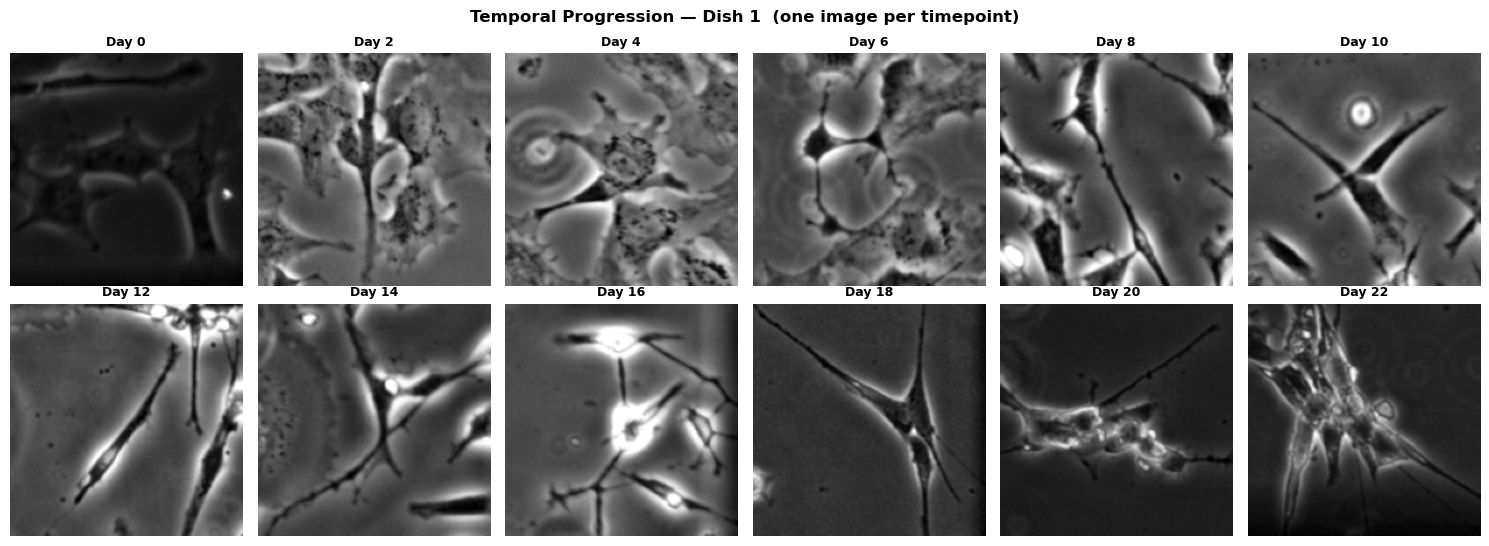

Saved → /Users/E.M.A./Desktop/CapstoneProject/outputs/plots_CoND/sample_preprocessed_images.png


In [4]:
## Visualization — Sample Preprocessed Images

def visualize_sample_images():
    pre_dir   = PROJECT_ROOT / cfg['paths']['preprocessed_dir']
    plots_dir = PROJECT_ROOT / cfg['paths']['plots_dir']
    plots_dir.mkdir(parents=True, exist_ok=True)
    task = cfg['ml']['task']

    if task == 'regression':
        days        = sorted(image_manifest['day'].unique())
        sample_rows = [image_manifest[(image_manifest['dish'] == 1) &
                        (image_manifest['day'] == d)].iloc[0] for d in days]
        ncols = 6
        nrows = (len(sample_rows) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.8))
        axes = np.array(axes).flatten()
        for i, row in enumerate(sample_rows):
            img = cv2.imread(str(pre_dir / row['preprocessed']), cv2.IMREAD_GRAYSCALE)
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f"Day {int(row['day'])}", fontsize=9, fontweight='bold')
            axes[i].axis('off')
        for j in range(len(sample_rows), len(axes)):
            axes[j].axis('off')
        plt.suptitle('Temporal Progression — Dish 1  (one image per timepoint)',
                     fontsize=12, fontweight='bold')
    else:
        # classification: mix of diff + undiff
        diff_rows   = image_manifest[image_manifest['label'] == 1].sample(5, random_state=42)
        undiff_rows = image_manifest[image_manifest['label'] == 0].sample(4, random_state=42)
        sample_rows = pd.concat([diff_rows, undiff_rows]).to_dict('records')
        ncols, nrows = 3, 3
        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.8))
        axes = axes.flatten()
        for i, row in enumerate(sample_rows):
            img = cv2.imread(str(pre_dir / row['preprocessed']), cv2.IMREAD_GRAYSCALE)
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title('Diff' if row['label'] == 1 else 'Undiff',
                              fontsize=9, fontweight='bold')
            axes[i].axis('off')
        plt.suptitle('Sample Images — Differentiated vs Undifferentiated',
                     fontsize=12, fontweight='bold')

    plt.tight_layout()
    out = plots_dir / 'sample_preprocessed_images.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")

visualize_sample_images()

## Module 2 — Patch Generation (Not Applicable)

Patching is omitted for this dataset. CoND images are already 200×200 px crops of individual cells, so each image is treated as a single sample. `image_manifest` (one row per image) is used directly in place of a patch manifest.

In [5]:
# Module 2 intentionally not implemented.
print("Module 2 (Patching): SKIPPED")
print(f"Reason  : CoND images are already 200×200 individual-cell crops.")
print(f"Samples : {len(image_manifest)} (one per image, not per patch)")

Module 2 (Patching): SKIPPED
Reason  : CoND images are already 200×200 individual-cell crops.
Samples : 1595 (one per image, not per patch)


## Module 3 — Feature Extraction

Morphological features are extracted from each 200×200 image using watershed segmentation (implemented in `src/pipeline_utils.py`). Five features are computed per image:

- `soma_area_mean` — average cell body area (px²)
- `circularity_mean` — roundness of cell bodies; 1 = perfect circle, 0 = elongated
- `neurite_length` — total skeletonised neurite length (px)
- `branch_count` — number of branch points in the neurite network
- `neurite_density` — neurite length normalised by cell area

In [6]:
def segment_image(img_float):
    """Background subtraction + watershed segmentation for phase contrast."""
    background = gaussian_filter(img_float, sigma=20)
    deviation  = np.abs(img_float - background)
    thresh     = np.percentile(deviation, 88)
    binary     = deviation > thresh
    binary     = morphology.remove_small_objects(binary, min_size=150)
    binary     = morphology.remove_small_holes(binary, area_threshold=300)

    distance   = ndi.distance_transform_edt(binary)
    coords     = peak_local_max(distance, min_distance=15, labels=binary)
    mask       = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels     = watershed(-distance, markers, mask=binary)
    return labels > 0


def extract_features(image_path):
    """Extract 5 core morphological features from a single preprocessed image."""
    img       = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    img_float = img.astype(np.float32) / 255.0
    binary    = segment_image(img_float)

    labeled  = measure.label(binary)
    regions  = measure.regionprops(labeled, intensity_image=img_float)
    if not regions:
        return None

    areas         = [r.area      for r in regions]
    perimeters    = [r.perimeter for r in regions]
    circularities = [4 * np.pi * r.area / (r.perimeter ** 2)
                     if r.perimeter > 0 else 0 for r in regions]

    skeleton        = skeletonize(binary)
    neurite_length  = int(skeleton.sum())
    kernel          = np.ones((3, 3), dtype=int)
    neighbour_count = convolve(skeleton.astype(int), kernel)
    branch_points   = int(((neighbour_count >= 4) & skeleton).sum())
    total_area      = binary.sum()
    neurite_density = neurite_length / total_area if total_area > 0 else 0

    return {
        'soma_area_mean'   : np.mean(areas),
        'circularity_mean' : np.mean(circularities),
        'neurite_length'   : neurite_length,
        'branch_count'     : branch_points,
        'neurite_density'  : neurite_density,
    }


def run_feature_extraction():
    pre_dir      = PROJECT_ROOT / cfg['paths']['preprocessed_dir']
    features_dir = PROJECT_ROOT / cfg['paths']['features_dir']
    features_dir.mkdir(parents=True, exist_ok=True)

    feature_cols = [
        'soma_area_mean', 'circularity_mean',
        'neurite_length', 'branch_count', 'neurite_density'
    ]
    rows = []
    task = cfg['ml']['task']

    for _, row in image_manifest.iterrows():
        img_path = pre_dir / row['preprocessed']
        feats    = extract_features(img_path)
        if feats is None:
            print(f"  WARNING: No regions in {row['preprocessed']} — skipping.")
            continue

        if task == 'regression':
            entry = {
                'image_id': row['image_id'],
                'dish'    : row['dish'],
                'day'     : row['day'],
                'label'   : row['label'],
            }
        else:
            entry = {
                'image_id'  : row['image_id'],
                'class_name': row['class_name'],
                'label'     : row['label'],
            }
        entry.update(feats)
        rows.append(entry)

    df = pd.DataFrame(rows)
    df.to_csv(features_dir / 'raw_features.csv', index=False)
    print(f"Extracted  : {len(df)} images")
    print(f"Features   : {feature_cols}")
    if task == 'regression':
        print(f"\nDay distribution:\n{df['day'].value_counts().sort_index().to_string()}")
    else:
        print(f"\nLabel distribution:\n{df['label'].value_counts().to_string()}")
    return df, feature_cols


features_df, feature_cols = run_feature_extraction()
features_df[['soma_area_mean', 'circularity_mean', 'neurite_length',
             'branch_count', 'neurite_density']].describe()

Extracted  : 1595 images
Features   : ['soma_area_mean', 'circularity_mean', 'neurite_length', 'branch_count', 'neurite_density']

Day distribution:
day
0     166
2     114
4     104
6      78
8     144
10    130
12    143
14    139
16    130
18    140
20    147
22    160


,soma_area_mean,circularity_mean,neurite_length,branch_count,neurite_density
count,1595.000000,1595.000000,1595.000000,1595.000000,1595.000000
mean,962.458893,0.312337,387.188715,32.886520,0.127166
std,866.413719,0.100805,98.385755,18.865809,0.027860
min,202.000000,0.030719,119.000000,0.000000,0.042007
25%,428.690476,0.250338,320.000000,19.000000,0.110593
50%,658.250000,0.314997,385.000000,29.000000,0.129022
75%,1119.916667,0.378647,452.000000,43.000000,0.146115
max,5094.000000,0.640320,768.000000,121.000000,0.224906


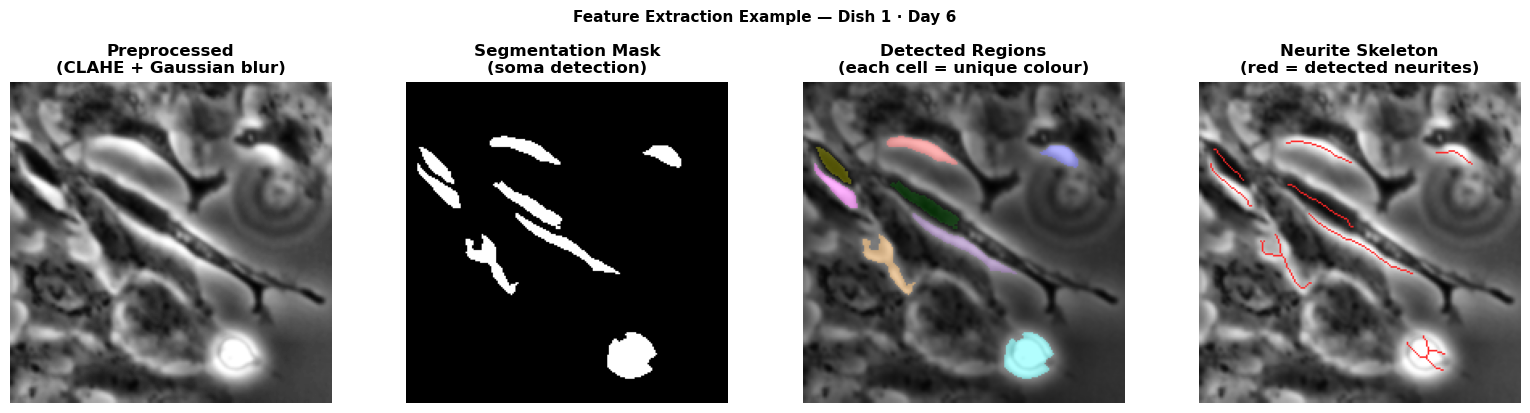


Extracted features for this image:
  soma_area_mean           :   321.2500  █████████████████████████████
  circularity_mean         :     0.4301  
  neurite_length           :   332.0000  ██████████████████████████████
  branch_count             :    12.0000  █
  neurite_density          :     0.1292  


In [7]:
## Visualization — Feature Extraction Pipeline

def visualize_feature_extraction():
    from skimage.color import label2rgb
    pre_dir   = PROJECT_ROOT / cfg['paths']['preprocessed_dir']
    plots_dir = PROJECT_ROOT / cfg['paths']['plots_dir']
    plots_dir.mkdir(parents=True, exist_ok=True)
    task = cfg['ml']['task']

    row       = image_manifest.sample(1, random_state=7).iloc[0]
    img_path  = pre_dir / row['preprocessed']
    img       = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img_float = img.astype(np.float32) / 255.0
    binary    = segment_image(img_float)
    labeled   = measure.label(binary)
    skeleton  = skeletonize(binary)

    region_overlay = label2rgb(labeled, image=img_float, bg_label=0)
    skel_overlay   = np.stack([img_float] * 3, axis=-1)
    skel_overlay[skeleton] = [1.0, 0.15, 0.15]

    if task == 'regression':
        title = f"Feature Extraction Example — Dish {int(row['dish'])} · Day {int(row['day'])}"
    else:
        lbl   = 'Differentiated' if row['label'] == 1 else 'Undifferentiated'
        title = f"Feature Extraction Example — {lbl}"

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img, cmap='gray');    axes[0].set_title('Preprocessed\n(CLAHE + Gaussian blur)', fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(binary, cmap='gray'); axes[1].set_title('Segmentation Mask\n(soma detection)',    fontweight='bold'); axes[1].axis('off')
    axes[2].imshow(region_overlay);      axes[2].set_title('Detected Regions\n(each cell = unique colour)', fontweight='bold'); axes[2].axis('off')
    axes[3].imshow(skel_overlay);        axes[3].set_title('Neurite Skeleton\n(red = detected neurites)',   fontweight='bold'); axes[3].axis('off')
    plt.suptitle(title, fontsize=11, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(plots_dir / 'feature_extraction_example.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nExtracted features for this image:")
    feats   = extract_features(img_path)
    max_val = max(feats.values()) if feats else 1
    for k, v in feats.items():
        bar = '█' * int(min(v / max_val, 1.0) * 30)
        print(f"  {k:25s}: {v:>10.4f}  {bar}")

visualize_feature_extraction()

## Modules 4a / 4b — Before and After Feature Tables

The feature table is split into two groups representing the morphological state before and after a differentiation event:

- `label == 0` (undifferentiated) → **before** state  
- `label == 1` (differentiated) → **after** state

This split reflects the cross-sectional nature of the CoND dataset: undifferentiated cells serve as the morphological baseline, and differentiated cells represent the post-treatment state.

In [8]:
task = cfg['ml']['task']

if task == 'regression':
    # Regression: day 0 = pre-treatment baseline; day 2–22 = post-treatment
    before_df = features_df[features_df['day'] == 0].copy().reset_index(drop=True)
    after_df  = features_df[features_df['day'] > 0].copy().reset_index(drop=True)
    print(f"Before (day 0)    : {len(before_df)} images across {before_df['dish'].nunique()} dishes")
    print(f"After  (day 2–22) : {len(after_df)} images across {after_df['dish'].nunique()} dishes, "
          f"{after_df['day'].nunique()} timepoints")
else:
    # Classification: undifferentiated = before state; differentiated = after state
    before_df = features_df[features_df['label'] == 0].copy().reset_index(drop=True)
    after_df  = features_df[features_df['label'] == 1].copy().reset_index(drop=True)
    print(f"Before (undifferentiated) : {len(before_df)} images")
    print(f"After  (differentiated)   : {len(after_df)} images")

Before (day 0)    : 166 images across 4 dishes
After  (day 2–22) : 1429 images across 4 dishes, 11 timepoints


## Module 5 — Delta Computation and Pairing

Each sample is constructed by pairing one *before* image (undifferentiated) with one *after* image, then computing the per-feature delta (`after − before`). Two pair types are created:

| Pair type | Before | After | Label | Interpretation |
|-----------|--------|-------|-------|----------------|
| Positive | undiff image | diff image | 1 | Morphological change consistent with differentiation |
| Negative | undiff image | different undiff image | 0 | No differentiation — near-zero deltas expected |

Pairing is random with a fixed seed (`random_seed: 42`). The dataset contains 176 positive + 176 negative pairs = 352 real rows.

In [9]:
def run_delta_computation():
    """
    CLASSIFICATION mode — synthetic cross-sectional pairing.
    Positive (label=1): undiff → diff   — large structured deltas expected.
    Negative (label=0): undiff → undiff — near-zero deltas expected.
    """
    PAIR_SEED = cfg['pairing']['random_seed']

    # Positive pairs: undiff to diff (label = 1)
    after_shuffled = after_df.sample(frac=1, random_state=PAIR_SEED).reset_index(drop=True)
    positive_rows  = []
    for i, b_row in before_df.iterrows():
        a_row = after_shuffled.iloc[i % len(after_shuffled)]
        entry = {'before_image_id': b_row['image_id'], 'after_image_id': a_row['image_id'],
                 'label': 1, 'pair_type': 'synthetic_positive'}
        for col in feature_cols:
            entry[f'delta_{col}'] = float(a_row[col]) - float(b_row[col])
        positive_rows.append(entry)

    # Negative pairs: undiff to undiff (label = 0)
    before_shuffled = before_df.sample(frac=1, random_state=PAIR_SEED + 1).reset_index(drop=True)
    negative_rows   = []
    n_before        = len(before_df)
    for i, b_row in before_df.iterrows():
        a_row = before_shuffled.iloc[(i + n_before // 2) % n_before]
        entry = {'before_image_id': b_row['image_id'], 'after_image_id': a_row['image_id'],
                 'label': 0, 'pair_type': 'synthetic_negative'}
        for col in feature_cols:
            entry[f'delta_{col}'] = float(a_row[col]) - float(b_row[col])
        negative_rows.append(entry)

    df = pd.concat([pd.DataFrame(positive_rows), pd.DataFrame(negative_rows)], ignore_index=True)
    print(f"Positive pairs (label=1, undiff→diff)   : {len(positive_rows)}")
    print(f"Negative pairs (label=0, undiff→undiff) : {len(negative_rows)}")
    print(f"Total                                    : {len(df)}")
    return df


def run_delta_computation_regression():
    """
    REGRESSION mode — real longitudinal pairing.
    For each dish: pairs every 0day image with one randomly selected image
    from each later timepoint (2, 4, ..., 22 days) in the same dish.
    label = day number of the after image (continuous regression target).
    """
    PAIR_SEED = cfg['pairing']['random_seed']
    rng  = np.random.default_rng(PAIR_SEED)
    rows = []

    for dish_num in sorted(before_df['dish'].unique()):
        dish_before = before_df[before_df['dish'] == dish_num].reset_index(drop=True)
        dish_after  = after_df[after_df['dish'] == dish_num].reset_index(drop=True)

        for day_val in sorted(dish_after['day'].unique()):
            day_pool = dish_after[dish_after['day'] == day_val].reset_index(drop=True)

            for _, b_row in dish_before.iterrows():
                # Pick one random after-image from this timepoint in this dish
                a_row = day_pool.iloc[int(rng.integers(len(day_pool)))]
                entry = {
                    'before_image_id': b_row['image_id'],
                    'after_image_id' : a_row['image_id'],
                    'dish'           : dish_num,
                    'day'            : day_val,
                    'label'          : float(day_val),
                    'pair_type'      : 'real_longitudinal',
                }
                for col in feature_cols:
                    entry[f'delta_{col}'] = float(a_row[col]) - float(b_row[col])
                rows.append(entry)

    df = pd.DataFrame(rows)
    print(f"Real longitudinal pairs : {len(df)}")
    print(f"Dishes                  : {df['dish'].nunique()}")
    print(f"Label (day) distribution:\n{df['day'].value_counts().sort_index().to_string()}")
    return df


#Branch on task
task = cfg['ml']['task']

if task == 'regression':
    delta_df = run_delta_computation_regression()
else:
    delta_df = run_delta_computation()

delta_df.head()

Real longitudinal pairs : 1826
Dishes                  : 4
Label (day) distribution:
day
2     166
4     166
6     166
8     166
10    166
12    166
14    166
16    166
18    166
20    166
22    166


,before_image_id,after_image_id,dish,day,label,pair_type,delta_soma_area_mean,delta_circularity_mean,delta_neurite_length,delta_branch_count,delta_neurite_density
0,d1_t00_ph001,d1_t02_ph169,1,2,2.0,real_longitudinal,-4.166667,0.018308,-43.0,-16.0,-0.014307
1,d1_t00_ph002,d1_t02_ph185,1,2,2.0,real_longitudinal,748.333333,0.026571,-12.0,5.0,-0.045761
2,d1_t00_ph003,d1_t02_ph182,1,2,2.0,real_longitudinal,-1207.750000,-0.034916,-213.0,-78.0,-0.023406
3,d1_t00_ph004,d1_t02_ph177,1,2,2.0,real_longitudinal,-1990.000000,0.191359,20.0,12.0,-0.016067
4,d1_t00_ph005,d1_t02_ph177,1,2,2.0,real_longitudinal,454.250000,0.015199,-14.0,-9.0,-0.015075


## Module 6 — Tabular Dataset Construction

The paired feature rows and computed delta features are merged into a single tabular dataset. Each row contains:

- `before_*` — 5 features from the undifferentiated (before) image  
- `after_*` — 5 features from the paired (after) image  
- `delta_*` — element-wise difference: `after − before` for each feature  
- `label` — 0 (no differentiation) or 1 (differentiation)  
- `pair_type` — records whether the pair is cross-sectional or longitudinal

In [10]:
def run_dataset_construction():
    features_dir = PROJECT_ROOT / cfg['paths']['features_dir']
    task         = cfg['ml']['task']

    before_feat = before_df[['image_id'] + feature_cols].copy()
    before_feat = before_feat.rename(columns={col: f'before_{col}' for col in feature_cols}
                  ).rename(columns={'image_id': 'before_image_id'})

    after_feat = after_df[['image_id'] + feature_cols].copy()
    after_feat = after_feat.rename(columns={col: f'after_{col}' for col in feature_cols}
                 ).rename(columns={'image_id': 'after_image_id'})

    dataset = delta_df.merge(before_feat, on='before_image_id', how='left')
    dataset = dataset.merge(after_feat,  on='after_image_id',  how='left')
    dataset['is_synthetic'] = False

    id_cols     = ['before_image_id', 'after_image_id', 'pair_type']
    before_cols = [f'before_{col}' for col in feature_cols]
    after_cols  = [f'after_{col}'  for col in feature_cols]
    delta_cols_ = [f'delta_{col}'  for col in feature_cols]
    # regression: keep 'dish' for Leave-One-Dish-Out cross-validation
    meta_cols   = (['dish', 'label', 'is_synthetic'] if task == 'regression'
                   else ['label', 'is_synthetic'])

    dataset = dataset[id_cols + before_cols + after_cols + delta_cols_ + meta_cols]

    out_path = features_dir / 'dataset.csv'
    dataset.to_csv(out_path, index=False)

    print(f"Dataset shape : {dataset.shape}")
    if task == 'regression':
        print(f"Label (day) stats:\n{dataset['label'].describe().to_string()}")
        print(f"Dishes       : {dataset['dish'].nunique()} ({sorted(dataset['dish'].unique())})")
    else:
        print(f"Label breakdown:\n{dataset['label'].value_counts().to_string()}")
    print(f"\nColumn groups:")
    print(f"  Before : {len(before_cols)} features  (e.g. before_soma_area_mean)")
    print(f"  After  : {len(after_cols)} features  (e.g. after_soma_area_mean)")
    print(f"  Delta  : {len(delta_cols_)} features  (e.g. delta_neurite_length)")
    print(f"\nSaved to: {out_path}")
    return dataset, before_cols, after_cols, delta_cols_


dataset, before_cols, after_cols, delta_cols = run_dataset_construction()
dataset.head()


Dataset shape : (1826, 21)
Label (day) stats:
count    1826.000000
mean       12.000000
std         6.326288
min         2.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        22.000000
Dishes       : 4 ([1, 2, 3, 4])

Column groups:
  Before : 5 features  (e.g. before_soma_area_mean)
  After  : 5 features  (e.g. after_soma_area_mean)
  Delta  : 5 features  (e.g. delta_neurite_length)

Saved to: /Users/E.M.A./Desktop/CapstoneProject/outputs/features_CoND/dataset.csv


,before_image_id,after_image_id,pair_type,before_soma_area_mean,before_circularity_mean,before_neurite_length,before_branch_count,before_neurite_density,after_soma_area_mean,after_circularity_mean,...,after_branch_count,after_neurite_density,delta_soma_area_mean,delta_circularity_mean,delta_neurite_length,delta_branch_count,delta_neurite_density,dish,label,is_synthetic
0,d1_t00_ph001,d1_t02_ph169,real_longitudinal,457.333333,0.273389,450,16,0.163994,453.166667,0.291697,...,0,0.149687,-4.166667,0.018308,-43.0,-16.0,-0.014307,1,2.0,False
1,d1_t00_ph002,d1_t02_ph185,real_longitudinal,398.333333,0.296167,331,5,0.138494,1146.666667,0.322739,...,10,0.092733,748.333333,0.026571,-12.0,5.0,-0.045761,1,2.0,False
2,d1_t00_ph003,d1_t02_ph182,real_longitudinal,1938.000000,0.315129,587,98,0.151445,730.250000,0.280213,...,20,0.128038,-1207.750000,-0.034916,-213.0,-78.0,-0.023406,1,2.0,False
3,d1_t00_ph004,d1_t02_ph177,real_longitudinal,3371.000000,0.088567,378,24,0.112133,1381.000000,0.279926,...,36,0.096066,-1990.000000,0.191359,20.0,12.0,-0.016067,1,2.0,False
4,d1_t00_ph005,d1_t02_ph177,real_longitudinal,926.750000,0.264727,412,45,0.111141,1381.000000,0.279926,...,36,0.096066,454.250000,0.015199,-14.0,-9.0,-0.015075,1,2.0,False


## Module 7 — Tabular Jitter Augmentation

Gaussian jitter augmentation is applied to the **training split only**. For each real training row, a synthetic copy is generated by adding zero-mean Gaussian noise scaled by `α × std(feature)` (α = 0.05). Augmentation continues until the training set reaches `target_rows` (7,000 by default). The test split is never augmented.

In [11]:
def run_augmentation(dataset, before_cols, after_cols, delta_cols):
    features_dir = PROJECT_ROOT / cfg['paths']['features_dir']

    alpha       = cfg['augmentation']['alpha']
    target_rows = cfg['augmentation']['target_rows']
    rng         = np.random.default_rng(cfg['augmentation']['random_seed'])
    aug_cols    = before_cols + after_cols + delta_cols

    real_df  = dataset[dataset['is_synthetic'] == False].copy()
    col_stds = real_df[aug_cols].std()

    rows_needed    = target_rows - len(real_df)
    synthetic_rows = []

    while len(synthetic_rows) < rows_needed:
        base = real_df.sample(1, random_state=int(rng.integers(1e6))).iloc[0].copy()
        for col in aug_cols:
            base[col] += rng.normal(0, alpha * col_stds[col])
        base['is_synthetic'] = True
        synthetic_rows.append(base)

    synthetic_df = pd.DataFrame(synthetic_rows)
    augmented_df = pd.concat([real_df, synthetic_df], ignore_index=True)

    out_path = features_dir / 'augmented_dataset.csv'
    augmented_df.to_csv(out_path, index=False)

    print(f"Real rows      : {len(real_df)}")
    print(f"Synthetic rows : {len(synthetic_df)}")
    print(f"Total rows     : {len(augmented_df)}")
    return augmented_df


augmented_df = run_augmentation(dataset, before_cols, after_cols, delta_cols)
print(f"Augmented shape: {augmented_df.shape}")

Real rows      : 1826
Synthetic rows : 5174
Total rows     : 7000
Augmented shape: (7000, 21)


## Module 8 — ML Model Training

Three models are trained on the **delta features only** (`delta_soma_area_mean`, `delta_circularity_mean`, `delta_neurite_length`, `delta_branch_count`, `delta_neurite_density`). Before/after absolute features are excluded to prevent data leakage.

Training uses the augmented dataset; evaluation uses held-out real rows only. Two evaluation protocols are run:

1. **Single train/test split** (80/20) — baseline performance metrics  
2. **Leave-One-Dish-Out cross-validation** — one of the 4 CoND dishes held out per fold; reports mean ± std across folds

In [12]:
def run_ml_training(augmented_df, delta_cols):
    """
    Branches on cfg['ml']['task']:
    ─ 'classification' → XGBClassifier, RandomForestClassifier, SVC
                         Metrics: Accuracy, F1, ROC-AUC
    ─ 'regression'     → XGBRegressor, RandomForestRegressor, SVR
                         Metrics: RMSE, MAE, R²
    Input: ONLY delta_* features — no before_*/after_* (avoids data leakage).
    """
    models_dir  = PROJECT_ROOT / cfg['paths']['models_dir']
    results_dir = PROJECT_ROOT / cfg['paths']['results_dir']
    models_dir.mkdir(parents=True, exist_ok=True)
    results_dir.mkdir(parents=True, exist_ok=True)

    task   = cfg['ml']['task']
    X_cols = delta_cols
    print(f"Task           : {task.upper()}")
    print(f"Input features : {len(X_cols)} delta features only")
    print(f"  {X_cols}\n")

    real_data = augmented_df[augmented_df['is_synthetic'] == False].copy()

    n_test   = max(1, int(len(real_data) * cfg['ml']['test_size']))
    test_df  = real_data.sample(n=n_test, random_state=SEED)
    train_df = run_augmentation(real_data.drop(test_df.index), before_cols, after_cols, delta_cols)

    X_train = train_df[X_cols].fillna(0).values
    y_train = train_df['label'].values
    X_test  = test_df[X_cols].fillna(0).values
    y_test  = test_df['label'].values

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    print(f"Train rows : {len(X_train)}  (real: {len(real_data) - n_test}, synthetic: {len(train_df) - (len(real_data) - n_test)})")
    print(f"Test rows  : {len(X_test)} (real only)\n")

    #REGRESSION
    if task == 'regression':
        y_train = y_train.astype(float)
        y_test  = y_test.astype(float)
        print(f"Target range (test): {y_test.min():.0f}–{y_test.max():.0f} days\n")

        models = {
            'xgboost'       : xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
            'random_forest' : RandomForestRegressor(n_estimators=100, random_state=SEED),
            'svr'           : SVR(kernel='rbf', C=1.0),
        }

        results = {}
        for name, model in models.items():
            Xtr = X_train_sc if name == 'svr' else X_train
            Xte = X_test_sc  if name == 'svr' else X_test

            model.fit(Xtr, y_train)
            preds = model.predict(Xte)

            rmse = np.sqrt(mean_squared_error(y_test, preds))
            mae  = mean_absolute_error(y_test, preds)
            r2   = r2_score(y_test, preds)

            results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'model': model}

            print(f"── {name.upper()} ──")
            print(f"  RMSE : {rmse:.3f} days")
            print(f"  MAE  : {mae:.3f} days")
            print(f"  R²   : {r2:.4f}\n")

        best = max(results, key=lambda k: results[k]['r2'])
        print(f"Best model (R²): {best}  ({results[best]['r2']:.4f})")

    #CLASSIFICATION
    else:
        y_train = y_train.astype(int)
        y_test  = y_test.astype(int)
        print(f"Class balance (test): {dict(pd.Series(y_test).value_counts())}\n")

        models = {
            'xgboost'       : xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                  verbosity=0, eval_metric='logloss'),
            'random_forest' : RandomForestClassifier(n_estimators=100, random_state=SEED),
            'svc'           : SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED),
        }

        results = {}
        for name, model in models.items():
            Xtr = X_train_sc if name == 'svc' else X_train
            Xte = X_test_sc  if name == 'svc' else X_test

            model.fit(Xtr, y_train)
            preds      = model.predict(Xte)
            preds_prob = model.predict_proba(Xte)[:, 1]

            acc     = accuracy_score(y_test, preds)
            f1      = f1_score(y_test, preds, zero_division=0)
            roc_auc = roc_auc_score(y_test, preds_prob)

            results[name] = {'accuracy': acc, 'f1': f1, 'roc_auc': roc_auc, 'model': model}

            print(f"── {name.upper()} ──")
            print(f"  Accuracy : {acc:.4f}")
            print(f"  F1       : {f1:.4f}")
            print(f"  ROC-AUC  : {roc_auc:.4f}")
            print(classification_report(y_test, preds,
                  target_names=['no_change', 'differentiated'], zero_division=0))

        best = max(results, key=lambda k: results[k]['roc_auc'])
        print(f"\nBest model (ROC-AUC): {best}  ({results[best]['roc_auc']:.4f})")

    #Save metrics
    records = []
    for name, r in results.items():
        row = {'model': name}
        row.update({k: v for k, v in r.items() if k != 'model'})
        records.append(row)
    metrics_df = pd.DataFrame(records)
    csv_name   = f'{task}_single_split.csv'
    metrics_df.to_csv(results_dir / csv_name, index=False)
    print(f"\nMetrics saved → {results_dir / csv_name}")

    return results, X_cols, X_test, X_test_sc, y_test, scaler


results, X_cols, X_test, X_test_sc, y_test, scaler = run_ml_training(
    augmented_df, delta_cols
)


Task           : REGRESSION
Input features : 5 delta features only
  ['delta_soma_area_mean', 'delta_circularity_mean', 'delta_neurite_length', 'delta_branch_count', 'delta_neurite_density']

Real rows      : 1461
Synthetic rows : 5539
Total rows     : 7000
Train rows : 7000  (real: 1461, synthetic: 5539)
Test rows  : 365 (real only)

Target range (test): 2–22 days

── XGBOOST ──
  RMSE : 6.358 days
  MAE  : 5.130 days
  R²   : -0.0321

── RANDOM_FOREST ──
  RMSE : 5.998 days
  MAE  : 4.859 days
  R²   : 0.0814

── SVR ──
  RMSE : 5.834 days
  MAE  : 4.687 days
  R²   : 0.1310

Best model (R²): svr  (0.1310)

Metrics saved → /Users/E.M.A./Desktop/CapstoneProject/outputs/results_CoND/regression_single_split.csv


In [13]:
import joblib
models_dir = PROJECT_ROOT / cfg['paths']['models_dir']
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(results['random_forest']['model'], models_dir / 'rf_model.pkl')
joblib.dump(scaler, models_dir / 'scaler.pkl')
print(f"Saved → {models_dir / 'rf_model.pkl'}")
print(f"Saved → {models_dir / 'scaler.pkl'}")

Saved → /Users/E.M.A./Desktop/CapstoneProject/outputs/models_CoND/rf_model.pkl
Saved → /Users/E.M.A./Desktop/CapstoneProject/outputs/models_CoND/scaler.pkl


In [14]:
def run_grouped_kfold(dataset, delta_cols):
    """
    Regression: Leave-One-Dish-Out CV (4 folds, one per dish).
    Each fold trains on 3 dishes (augmented), tests on 1 dish (real only).
    Reports mean +/- std R2 -- a more honest robustness estimate than a single split.

    Classification: not applicable (no dish structure) -- single split is used.
    """
    task = cfg['ml']['task']

    if task != 'regression':
        print("Grouped k-fold: regression mode only.")
        print("Classification robustness is reported via the single 80/20 split above.")
        return

    if 'dish' not in dataset.columns:
        print("WARNING: 'dish' column not found. Re-run Module 6 in regression mode.")
        return

    real_data = dataset[dataset['is_synthetic'] == False].copy()
    dishes    = sorted(real_data['dish'].unique())
    print(f"Leave-One-Dish-Out Cross-Validation -- {len(dishes)} folds\n")

    fold_scores = {m: [] for m in ['xgboost', 'random_forest', 'svr']}

    for test_dish in dishes:
        train_real = real_data[real_data['dish'] != test_dish].copy()
        test_real  = real_data[real_data['dish'] == test_dish].copy()

        # Augment only training split -- test dish rows never seen during training
        train_aug  = run_augmentation(train_real, before_cols, after_cols, delta_cols)

        X_train = train_aug[delta_cols].fillna(0).values
        y_train = train_aug['label'].astype(float).values
        X_test  = test_real[delta_cols].fillna(0).values
        y_test  = test_real['label'].astype(float).values

        scaler     = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        fold_models = {
            'xgboost'       : xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
            'random_forest' : RandomForestRegressor(n_estimators=100, random_state=SEED),
            'svr'           : SVR(kernel='rbf', C=1.0),
        }

        print(f"Fold -- hold out dish {test_dish}  "
              f"(train={len(train_aug):,} rows | test={len(test_real)} real rows)")
        for name, model in fold_models.items():
            Xtr = X_train_sc if name == 'svr' else X_train
            Xte = X_test_sc  if name == 'svr' else X_test
            model.fit(Xtr, y_train)
            r2 = r2_score(y_test, model.predict(Xte))
            fold_scores[name].append(r2)
            print(f"  {name:15s}: R2 = {r2:.4f}")
        print()

    print("-- Leave-One-Dish-Out Summary ------------------------------------------")
    for name, scores in fold_scores.items():
        mean_r2 = np.mean(scores)
        std_r2  = np.std(scores)
        folds   = '  '.join([f'{s:.3f}' for s in scores])
        print(f"  {name:15s}: R2 = {mean_r2:.4f} +/- {std_r2:.4f}  |  per-dish: [{folds}]")
    print()
    print("NOTE: 4-fold std is a rough estimate due to small number of dishes.")
    print("      Consistent near-zero R2 across dishes confirms the weak regression")
    print("      signal is real and not a single-split artefact.")


run_grouped_kfold(dataset, delta_cols)


Leave-One-Dish-Out Cross-Validation -- 4 folds

Real rows      : 1342
Synthetic rows : 5658
Total rows     : 7000
Fold -- hold out dish 1  (train=7,000 rows | test=484 real rows)
  xgboost        : R2 = -0.0433
  random_forest  : R2 = 0.0595
  svr            : R2 = 0.1198

Real rows      : 1507
Synthetic rows : 5493
Total rows     : 7000
Fold -- hold out dish 2  (train=7,000 rows | test=319 real rows)
  xgboost        : R2 = -0.0480
  random_forest  : R2 = 0.0848
  svr            : R2 = 0.1923

Real rows      : 1430
Synthetic rows : 5570
Total rows     : 7000
Fold -- hold out dish 3  (train=7,000 rows | test=396 real rows)
  xgboost        : R2 = -0.0959
  random_forest  : R2 = -0.0083
  svr            : R2 = 0.2092

Real rows      : 1199
Synthetic rows : 5801
Total rows     : 7000
Fold -- hold out dish 4  (train=7,000 rows | test=627 real rows)
  xgboost        : R2 = -0.1731
  random_forest  : R2 = -0.0623
  svr            : R2 = 0.0187

-- Leave-One-Dish-Out Summary ----------------

## Module 9 — Interpretability (SHAP)

Feature importance is computed using two methods:

- **SHAP TreeExplainer** (XGBoost, Random Forest) — exact Shapley values for tree-based models. For classifiers, values for the positive class (`shap_values[:, :, 1]`) are used.
- **Permutation importance** (SVC) — each feature is randomly shuffled; the resulting drop in ROC-AUC is recorded over `n_repeats=10` shuffles.

Results identify which delta features most strongly predict differentiation outcome.


── SHAP: XGBOOST — Top 5 features ──
               feature  importance
    delta_branch_count    1.711826
 delta_neurite_density    1.518897
  delta_neurite_length    0.999382
  delta_soma_area_mean    0.812544
delta_circularity_mean    0.751200


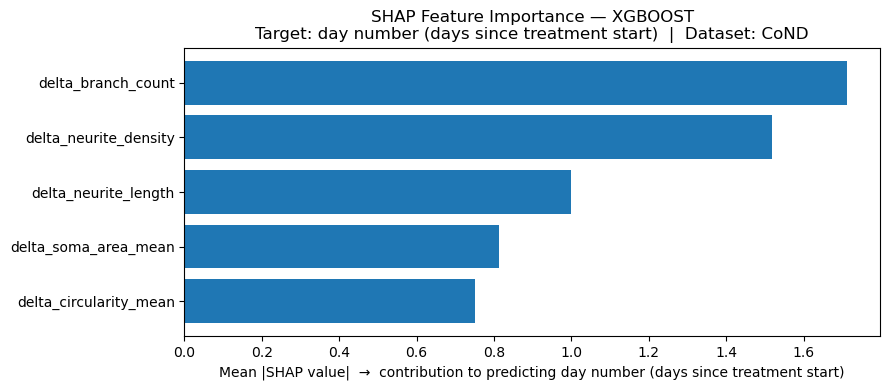


── SHAP: RANDOM_FOREST — Top 5 features ──
               feature  importance
    delta_branch_count    1.601005
 delta_neurite_density    1.333700
  delta_neurite_length    0.663521
  delta_soma_area_mean    0.482135
delta_circularity_mean    0.433904


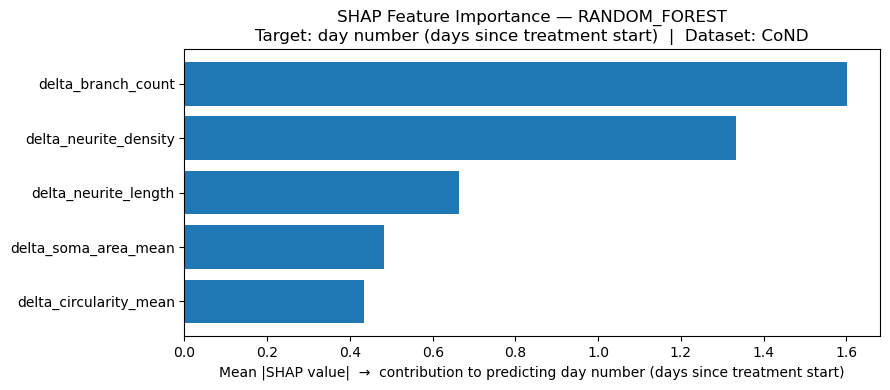


── Permutation Importance: SVR — Top 5 features ──
               feature  importance
    delta_branch_count    0.304573
 delta_neurite_density    0.253136
  delta_neurite_length    0.068805
  delta_soma_area_mean    0.043127
delta_circularity_mean    0.017880


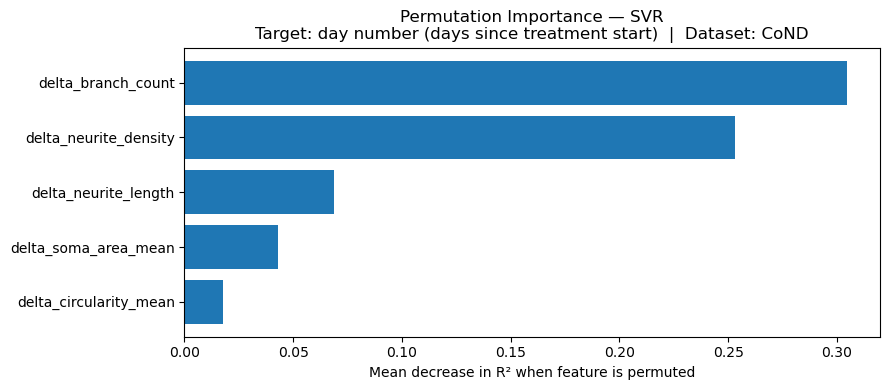


All plots saved to: /Users/E.M.A./Desktop/CapstoneProject/outputs/plots_CoND

Pipeline complete — mode: REGRESSION


In [15]:
def run_interpretability(results, X_cols, X_test, X_test_sc, y_test):
    plots_dir = PROJECT_ROOT / cfg['paths']['plots_dir']
    plots_dir.mkdir(parents=True, exist_ok=True)
    top_n = cfg['interpretability']['top_n_features']
    task  = cfg['ml']['task']

    task_label = (
        'day number (days since treatment start)' if task == 'regression'
        else 'differentiated vs undifferentiated'
    )

    # ── SHAP — XGBoost & Random Forest ───────────────────────────────────────
    for name in ['xgboost', 'random_forest']:
        if name not in results:
            continue
        model     = results[name]['model']
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)

        # Classifiers return list [class_0_vals, class_1_vals] → take class 1
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]

        mean_abs = np.abs(shap_vals).mean(axis=0)
        shap_df  = pd.DataFrame({
            'feature': X_cols, 'importance': mean_abs
        }).sort_values('importance', ascending=False).head(top_n)

        print(f"\n── SHAP: {name.upper()} — Top {top_n} features ──")
        print(shap_df.to_string(index=False))

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.barh(shap_df['feature'][::-1], shap_df['importance'][::-1])
        ax.set_xlabel(f'Mean |SHAP value|  →  contribution to predicting {task_label}')
        ax.set_title(
            f'SHAP Feature Importance — {name.upper()}\n'
            f'Target: {task_label}  |  Dataset: CoND'
        )
        plt.tight_layout()
        plt.savefig(plots_dir / f'shap_{name}_CoND.png', dpi=150)
        plt.show()

    # ── Permutation Importance — SVR / SVC ───────────────────────────────────
    perm_key     = 'svr'     if task == 'regression' else 'svc'
    scoring      = 'r2'      if task == 'regression' else 'roc_auc'
    metric_label = 'R²'      if task == 'regression' else 'ROC-AUC'

    if perm_key in results:
        print(f"\n── Permutation Importance: {perm_key.upper()} — Top {top_n} features ──")
        perm = permutation_importance(
            results[perm_key]['model'],
            X_test_sc, y_test,
            n_repeats=cfg['interpretability']['n_repeats'],
            random_state=SEED,
            scoring=scoring,
        )
        perm_df = pd.DataFrame({
            'feature': X_cols, 'importance': perm.importances_mean
        }).sort_values('importance', ascending=False).head(top_n)

        print(perm_df.to_string(index=False))

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1])
        ax.set_xlabel(f'Mean decrease in {metric_label} when feature is permuted')
        ax.set_title(
            f'Permutation Importance — {perm_key.upper()}\n'
            f'Target: {task_label}  |  Dataset: CoND'
        )
        plt.tight_layout()
        plt.savefig(plots_dir / f'permutation_{perm_key}_CoND.png', dpi=150)
        plt.show()

    print(f"\nAll plots saved to: {plots_dir}")


run_interpretability(results, X_cols, X_test, X_test_sc, y_test)

print("\n" + "="*60)
print(f"Pipeline complete — mode: {cfg['ml']['task'].upper()}")
print("="*60)